Dataset loaded successfully.
Graph created successfully.
Number of users: 4039
Number of friendships: 88234

--- Top 5 Most Influential Users ---

Most Popular Users (Degree Centrality):
User 107: Centrality = 0.2588
User 1684: Centrality = 0.1961
User 1912: Centrality = 0.1870
User 3437: Centrality = 0.1355
User 0: Centrality = 0.0859

Best Connectors (Betweenness Centrality):
User 107: Centrality = 0.4907
User 1684: Centrality = 0.3607
User 1912: Centrality = 0.2261
User 3437: Centrality = 0.2142
User 0: Centrality = 0.1474

Fastest Information Spreaders (Closeness Centrality):
User 107: Centrality = 0.4597
User 58: Centrality = 0.3974
User 428: Centrality = 0.3948
User 563: Centrality = 0.3939
User 1684: Centrality = 0.3936


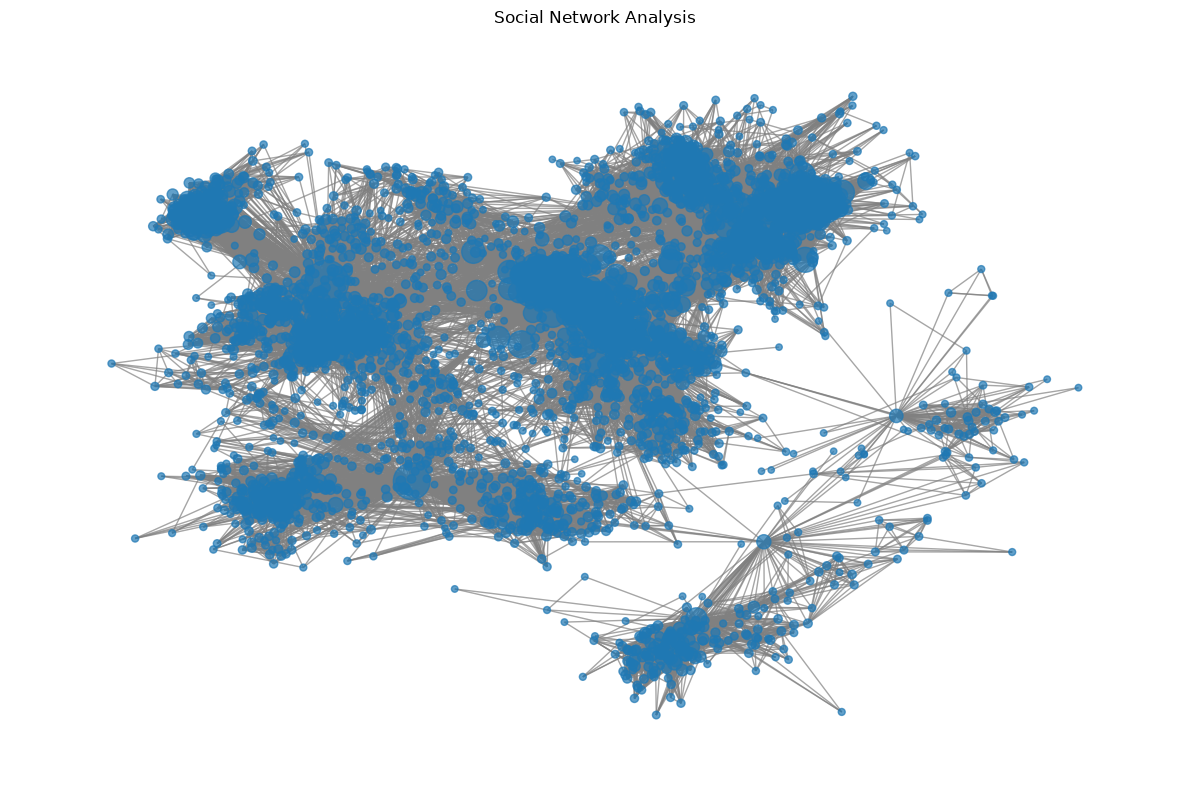

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load the dataset
file_path = "data_exp9.txt"

try:
    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
        names=["user_1", "user_2"]
    )
    print("Dataset loaded successfully.")

except FileNotFoundError:
    print(f"Error: {file_path} not found.")
    raise SystemExit

# Remove missing values, if any
df.dropna(inplace=True)

# 2. Create the Social Network Graph
G = nx.from_pandas_edgelist(
    df, source="user_1", target="user_2"
)

print("Graph created successfully.")
print("Number of users:", G.number_of_nodes())
print("Number of friendships:", G.number_of_edges())

# 3. Calculate Centrality Measures

# A. Degree Centrality
degree = nx.degree_centrality(G)
top_popular = sorted(
    degree.items(), key=lambda x: x[1], reverse=True
)[:5]

# B. Betweenness Centrality (approximation for speed)
k = min(200, G.number_of_nodes())
betweenness = nx.betweenness_centrality(
    G, k=k, seed=42
)
top_connectors = sorted(
    betweenness.items(), key=lambda x: x[1], reverse=True
)[:5]

# C. Closeness Centrality
closeness = nx.closeness_centrality(G)
top_spreaders = sorted(
    closeness.items(), key=lambda x: x[1], reverse=True
)[:5]

# 4. Display Results
print("\n--- Top 5 Most Influential Users ---")

print("\nMost Popular Users (Degree Centrality):")
for user, score in top_popular:
    print(f"User {user}: Centrality = {score:.4f}")

print("\nBest Connectors (Betweenness Centrality):")
for user, score in top_connectors:
    print(f"User {user}: Centrality = {score:.4f}")

print("\nFastest Information Spreaders (Closeness Centrality):")
for user, score in top_spreaders:
    print(f"User {user}: Centrality = {score:.4f}")

# 5. Visualize the Social Network
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42, k=0.15)

node_sizes = [
    20 + 5000 * degree[node]
    for node in G.nodes()
]

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=False,
    node_size=node_sizes,
    edge_color="gray",
    alpha=0.7
)

plt.title("Social Network Analysis")
plt.axis("off")
plt.tight_layout()
plt.show()